In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import FunctionTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBPipeline
from pipeline_tree_model import get_preprocessor, feature_engineer
import joblib
from load_data import get_dataset
from print_metric import print_results

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
pipe = IMBPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineer, validate=False)),
    ("preprocessor", get_preprocessor()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(random_state=42))
])

In [4]:
params_grid = {
    "model__objective": ["binary:logistic"],
    "model__n_estimators": [100, 200, 300, 400],
    "model__learning_rate": [0.01, 0.05, 0.5],
    "model__max_depth": [3, 4, 5, 6, 10],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2, 0.5],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.6, 0.8],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0.1, 1, 5]
}

In [5]:
random_search = RandomizedSearchCV(pipe, param_distributions=params_grid, cv=5, verbose=1, n_jobs=-1, scoring="roc_auc", n_iter=200, random_state=42)

In [6]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [7]:
y_pred = random_search.predict(X_test)

In [8]:
y_pred_proba = random_search.predict_proba(X_test)

In [9]:
y_train_pred = random_search.predict(X_train)
y_train_pred_proba = random_search.predict_proba(X_train)

In [10]:
print("TRAINING RESULTS")
print_results(y_train, y_train_pred, y_train_pred_proba[:, 1])
print("\n")
print("TESTING RESULTS")
print_results(y_test, y_pred, y_pred_proba[:, 1])

TRAINING RESULTS
Accuracy Score 0.8424068767908309
Recall Score 0.765
Precision Score 0.8116710875331565
ROC AUC Score 0.9163427357032459
F1 Score 0.7876447876447876
Confusion Matrix
[[576  71]
 [ 94 306]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       647
           1       0.81      0.77      0.79       400

    accuracy                           0.84      1047
   macro avg       0.84      0.83      0.83      1047
weighted avg       0.84      0.84      0.84      1047



TESTING RESULTS
Accuracy Score 0.8358778625954199
Recall Score 0.8
Precision Score 0.7766990291262136
ROC AUC Score 0.9105864197530864
F1 Score 0.7881773399014779
Confusion Matrix
[[139  23]
 [ 20  80]]
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       162
           1       0.78      0.80      0.79       100

    accuracy                           0.84       262


In [11]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__reg_lambda': 0.1,
 'model__reg_alpha': 0,
 'model__objective': 'binary:logistic',
 'model__n_estimators': 100,
 'model__min_child_weight': 1,
 'model__max_depth': 4,
 'model__learning_rate': 0.05,
 'model__gamma': 0.5,
 'model__colsample_bytree': 0.6}

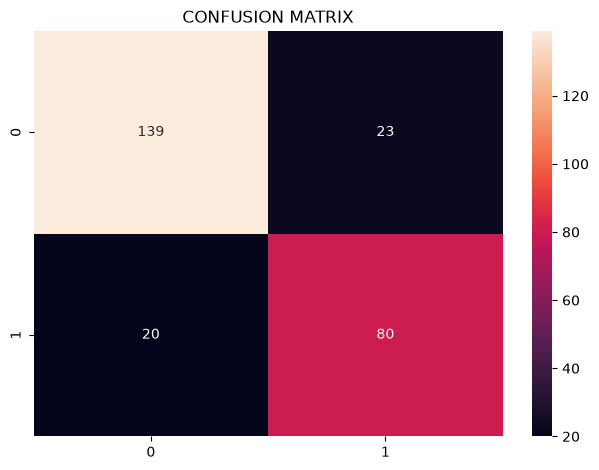

In [12]:
plt.title("CONFUSION MATRIX")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.tight_layout()
plt.savefig("images/confusion_matrix_xgboost.png", dpi=1200)
plt.show()

In [13]:
joblib.dump(random_search, "models/xgboost.pkl")
print("Model Saved")

Model Saved
